In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import platform


In [100]:
# matplot에서 한글 깨짐 방지를 위해서 기본 설정 폰트를 변경
# 사용하고 있는 컴퓨터의 os가 MAC인 경우
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')

In [59]:
# csv 폴더 안에 있는 card 폴더 안에 있는 오프라인.csv 로드
offline = pd.read_csv('../csv/card/오프라인.csv', encoding = 'CP949')

In [60]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   crym          2648 non-null   int64  
 1   tco_btc_nm    2648 non-null   object 
 2   ma_fem_dc     2648 non-null   int64  
 3   agegrp_dc     2648 non-null   int64  
 4   tco_btc_u_ct  2648 non-null   int64  
 5   tco_btc_u_am  2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.3+ KB


In [61]:
offline.head()

,crym,tco_btc_nm,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10


1. 컬럼의 이름을 변경 -> 항목정의서의 컬럼의 설명을 기준으로 컬럼의 이름을 변경
2. 결측치가 존재하는가?
    - non-null count을 기준으로 확인
    - 성별 컬럼에는 '-', 9 라는 데이터가 존재하는가?
3. 기준년월 데이터를 시계열 데이터로 변환
4. 남, 여 성별을 기준으로 연도별 건당 이용 금액의 평균은 어떠한 차이를 나타내는가?
5. 해당 데이터를 막대 그래프로 시각화

In [62]:
offline.columns = ['기준년월', '업종구분', '성별', '연령대','이용건수','이용금액']

In [63]:
offline.head()

,기준년월,업종구분,성별,연령대,이용건수,이용금액
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10


In [74]:
offline['기준년월'] = offline['기준년월'].astype('str')

In [89]:
# offline['기준년월'].map(
#     lambda x : datetime.strptime(x, '%Y%m')
# )

In [77]:
offline['기준년월'] = pd.to_datetime(offline['기준년월'], format = '%Y%m')

In [83]:
from datetime import datetime

In [88]:
offline['기준년월']

0      2019-01-01
1      2019-01-01
2      2019-01-01
3      2019-01-01
4      2019-01-01
          ...    
2643   2021-09-01
2644   2021-09-01
2645   2021-09-01
2646   2021-09-01
2647   2021-09-01
Name: 기준년월, Length: 2648, dtype: datetime64[ns]

In [ ]:
offline['기준년월'].dt.year
# 타입 int

In [95]:
offline['기준년'] = offline['기준년월'].dt.strftime('%Y')
# 타입 object

In [97]:
offline['건당이용금액'] = (offline['이용금액']/offline['이용건수']).round(2)

In [99]:
group_data = offline.groupby(['기준년','성별'])['건당이용금액'].mean()

In [65]:
offline['성별'].value_counts()

성별
2    1336
1    1312
Name: count, dtype: int64

<Axes: xlabel='기준년'>

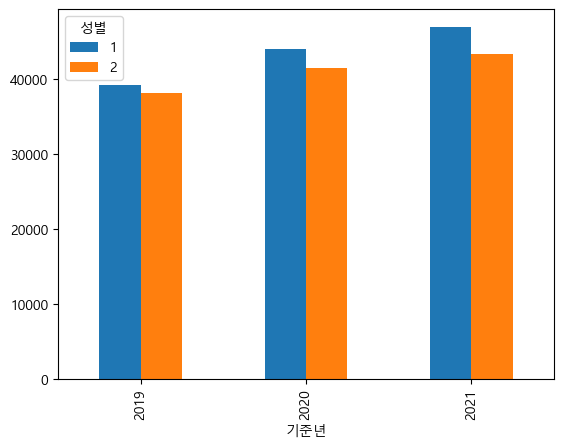

In [102]:
group_data.unstack().plot(kind = 'bar')

<Axes: xlabel='기준년'>

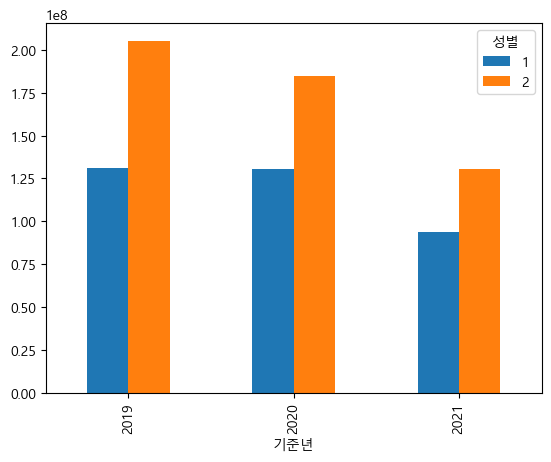

In [107]:
# 년도, 성별 이용 건수의 합계를 확인
offline.pivot_table(
    index= '기준년',
    columns= '성별',
    values= '이용건수',
    aggfunc='sum'
).plot(kind='bar')

In [109]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   기준년월    2648 non-null   datetime64[ns]
 1   업종구분    2648 non-null   object        
 2   성별      2648 non-null   int64         
 3   연령대     2648 non-null   int64         
 4   이용건수    2648 non-null   int64         
 5   이용금액    2648 non-null   float64       
 6   이용금액평균  2648 non-null   float64       
 7   기준년     2648 non-null   object        
 8   건당이용금액  2648 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 186.3+ KB


<Axes: xlabel='기준년월'>

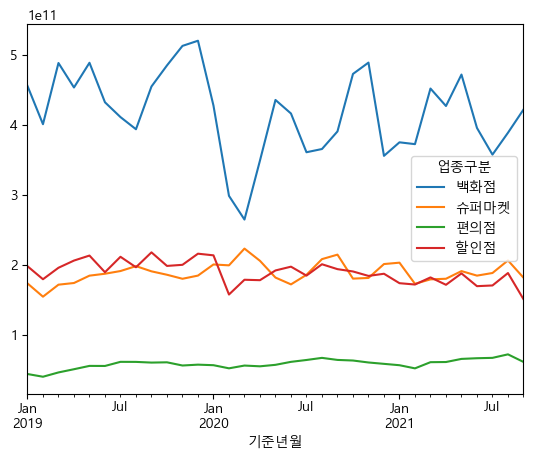

In [111]:
offline.pivot_table(
    index= '기준년월',
    columns= '업종구분',
    values='이용금액',
    aggfunc='sum'
).plot()

In [139]:
# 업종, 연령대 별로 이용금액의 합계, 총 이용건수
group_data2 = offline.pivot_table(
    index='기준년',
    columns=['업종구분','연령대'],
    values=['이용건수','이용금액'],
    aggfunc='sum',
    fill_value=0
)

In [140]:
df1 = group_data2['이용건수']

In [141]:
df2 = group_data2['이용금액']

In [142]:
offline['연령대'].value_counts()

연령대
10    264
20    264
30    264
70    264
40    264
50    264
60    264
90    264
80    264
0     233
1      39
Name: count, dtype: int64

<Axes: xlabel='연령대'>

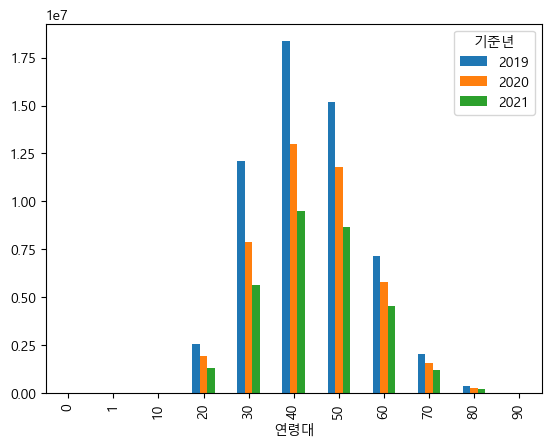

In [144]:
df1['백화점'].T.plot(kind = 'bar')

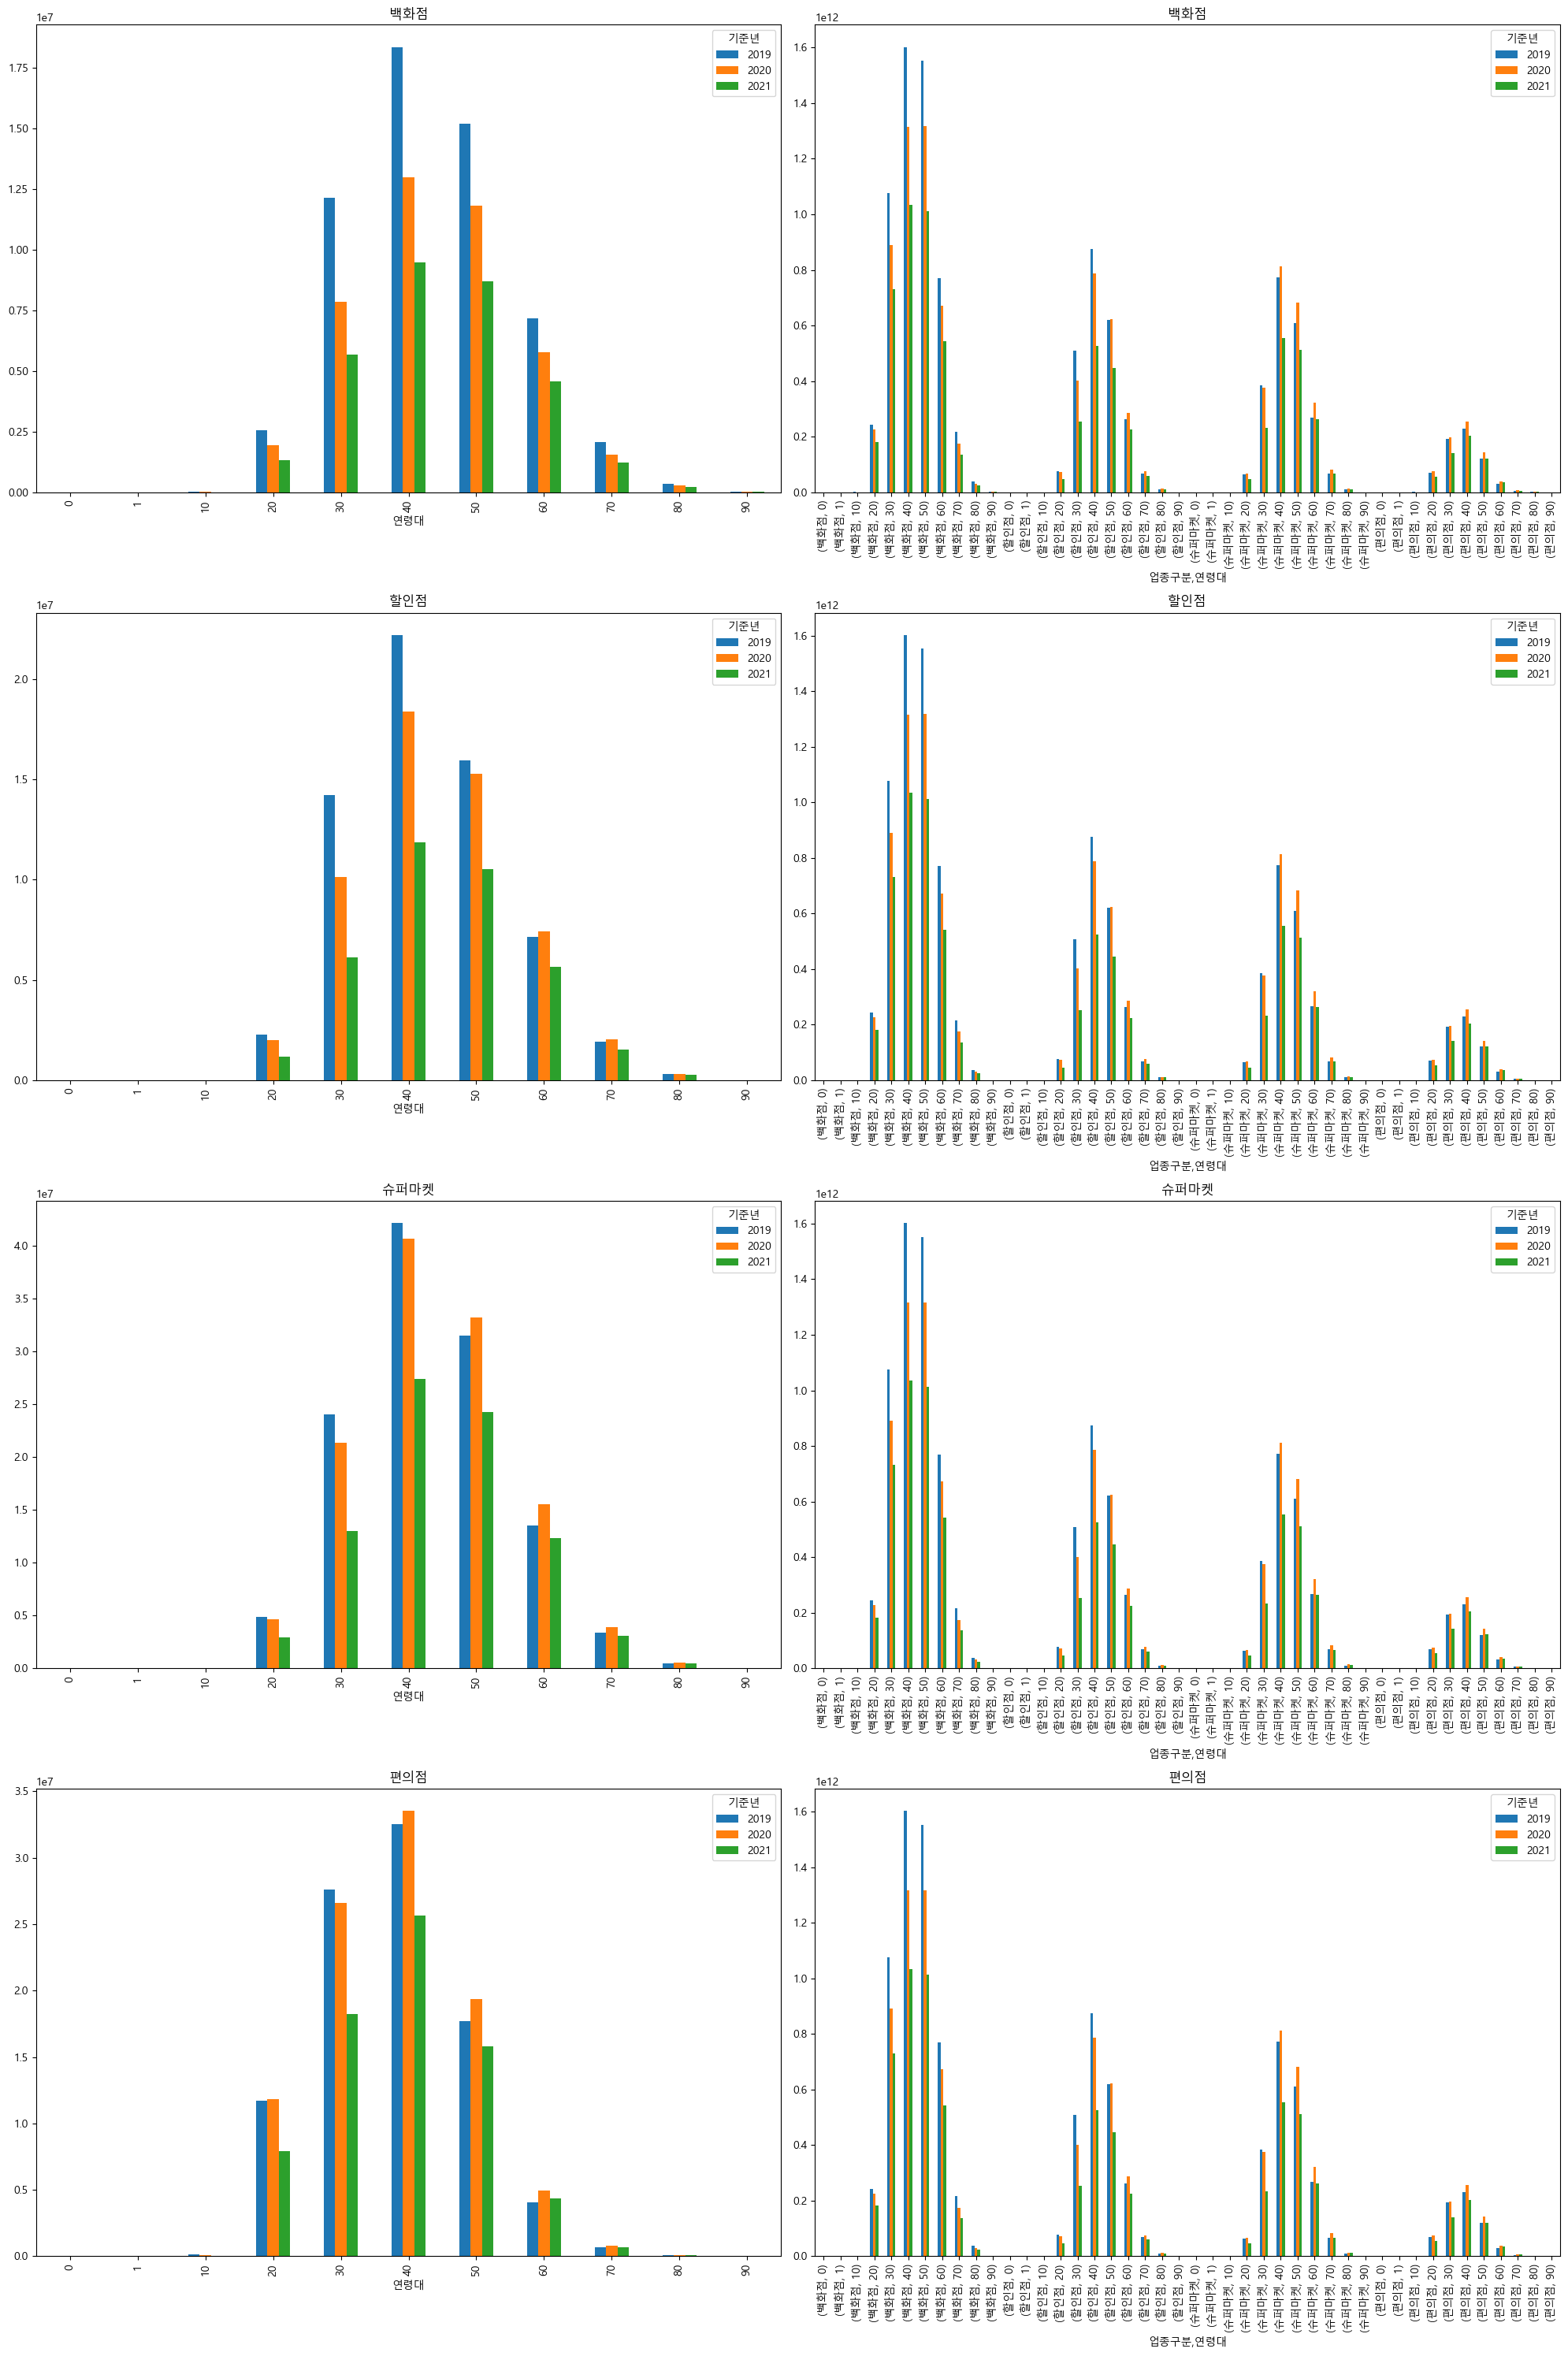

In [167]:
# 8(4*2)개의 공간을 생성하고 반복 실행할때 행이 1씩 증가하는 위치에 그래프 그린다
plt.figure(figsize=(20,30))
_list = offline['업종구분'].unique()
for i in range(len(_list)):
    ax1 = plt.subplot(4,2,i*2+1)
    # df1의 특정 컬럼을 선택하고 전치하여 막대그래프로 표시
    df1[_list[i]].T.plot(kind="bar", ax=ax1)
    # 그래프의 이름은 해당 컬럼의 이름으로 지정
    plt.title(_list[i])
    ax2 = plt.subplot(4,2,i*2+2)
    df2[_list].T.plot(kind='bar', ax=ax2)
    plt.title(_list[i])
plt.tight_layout()
plt.show()

In [150]:
offline['업종구분'].unique()

array(['백화점', '할인점', '슈퍼마켓', '편의점'], dtype=object)

In [161]:
offline[offline['연령대']==0]['업종구분'].value_counts()

업종구분
편의점     60
슈퍼마켓    59
할인점     57
백화점     57
Name: count, dtype: int64

In [170]:
offline = pd.read_csv('../csv/card/오프라인.csv', encoding = 'CP949')

In [171]:
online = pd.read_csv("./../csv/card/온라인.csv")

In [172]:
online.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   crym          651 non-null    int64
 1   ma_fem_dc     651 non-null    int64
 2   agegrp_dc     651 non-null    int64
 3   tco_btc_u_ct  651 non-null    int64
 4   tco_btc_u_am  651 non-null    int64
dtypes: int64(5)
memory usage: 25.6 KB


In [173]:
# offline 컬럼의 이름을 변경
offline.columns = ['기준년월','업종','성별','연령대','이용건수','이용금액']
# online 컬럼의 이름을 변경
online.columns = ['기준년월','성별','연령대','이용건수','이용금액']

In [174]:
# offline 과 online 데이터프레임의 구조를 동일하게 만들기 위해 online의 '업종 컬럼을 추가
online['업종'] = '온라인'

In [178]:
print(offline.columns)
print(online.columns)

Index(['기준년월', '업종', '성별', '연령대', '이용건수', '이용금액'], dtype='object')
Index(['기준년월', '성별', '연령대', '이용건수', '이용금액', '업종'], dtype='object')


In [181]:
df = pd.concat(
    [offline,online],
    axis='index',
    ignore_index=True
)

<Axes: xlabel='기준년월'>

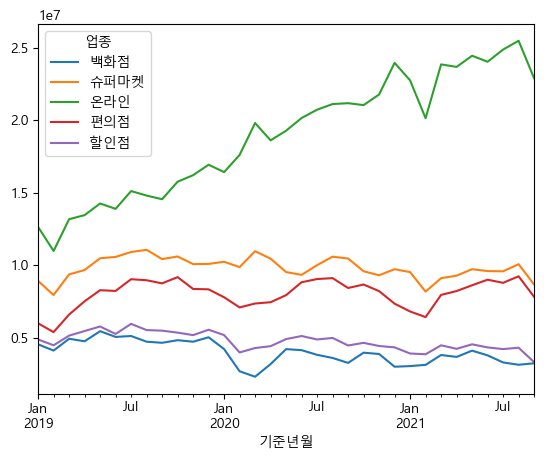

In [185]:
# 업종, 기준년월을 별 총 이용건수의 그래프 시각화
df.pivot_table(
    index = '기준년월',
    columns= '업종',
    values= '이용건수',
    aggfunc= 'sum'
).plot()

In [ ]:
# 그래프로 시각화를 기준년월을 x축으로 지정을 하니 숫자형으로 인식하여 그래프 간격에 문제가 발생
df['기준년월'] = pd.to_datetime(df['기준년월'],format="%Y%m")

- 온라인, 오프라인 기준으로 총이용건수, 총이용금액을 그래프로 시각화하여 출력
    - 파생변수 온/오프 생성하여 업종의 데이터의 값이 온라인이라면 0, 그외의 조건이라면 1

In [ ]:
# case1 : 반복문을 이용
# 반복횟수는 df의 길이만큼, 업종 컬럼의 value가 온라인인가?
# 빈 리스트에 반복할때마다 0,1 을 추가
# 만들어진 리스트를 새로운 파생변수에 추가한다
_list = []
# 위치를 기준으로 반복문
for i in range(len(df)):
    # i에 대입되는 데이터 -> 인덱스의 위치데이터
    if df.iloc[ i, -1] == '온라인':
        _list.append(0)
    else:
        _list.append(1)
_list

In [ ]:
_list = []
# 1차원 데이터(Series)를 기준으로 반복문 생성
for name in df['업종']:
    # name에 대입되는 데이터는 ? -> Series에 Values가 하나씩 대입
    if name == '온라인':
        _list.append(0)
    else:
        _list.append(1)

_list

In [ ]:
_list2 = []
i = 0
while i < len(df):
    if df['업종'].iloc[i] == '온라인':
        _list2.append(0)
    else:
        _list2.append(1)
    i += 1
_list2

In [198]:
_list == _list2

True

In [200]:
df['on/off'] = _list

<Axes: xlabel='기준년월'>

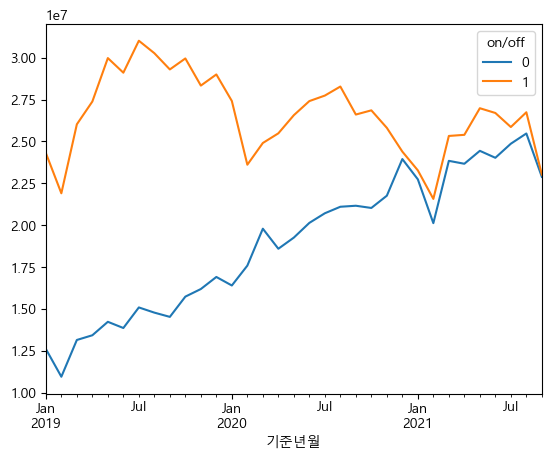

In [201]:
df.pivot_table(
    index='기준년월',
    columns='on/off',
    values='이용건수',
    aggfunc='sum'
).plot()

In [206]:
# on/off2 컬럼을 생섯하여 map() 데이터를 추가
# lambda에서 if문을 한줄로 표현
# '참인 경우 데이터' if 조건식 else '거짓인 경우 데이터'
df['on/off2'] = df['업종'].map(
    lambda x : 0 if x == '온라인' else 1
)

In [207]:
df['on/off'] == df['on/off2']

0       True
1       True
2       True
3       True
4       True
        ... 
3294    True
3295    True
3296    True
3297    True
3298    True
Length: 3299, dtype: bool

In [209]:
# 파생변수를 미리 생성하여 기본값을 설정
df['on/off3'] = 1

flag = df['업종'] == '온라인'

df.loc[flag, 'on/off3'] = 0

In [213]:
(df['on/off'] + df['on/off2'] + df['on/off3']).unique()

array([3, 0])

In [214]:
df.loc[:, 'on/off' : 'on/off3'].sum(axis=1).value_counts()

3    2648
0     651
Name: count, dtype: int64

<Axes: xlabel='기준년월'>

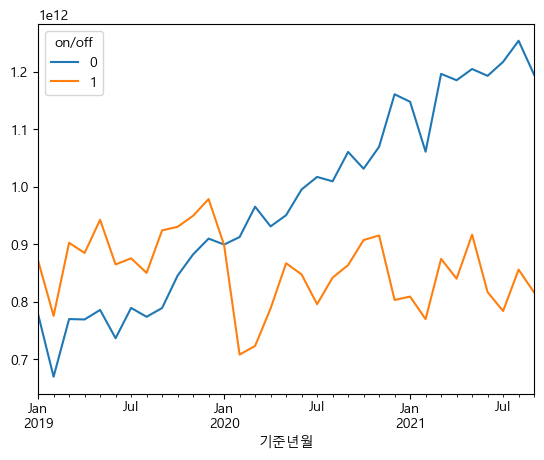

In [215]:
df.pivot_table(
    index='기준년월',
    columns='on/off',
    values='이용금액',
    aggfunc='sum'
).plot()

<Axes: xlabel='기준년월'>

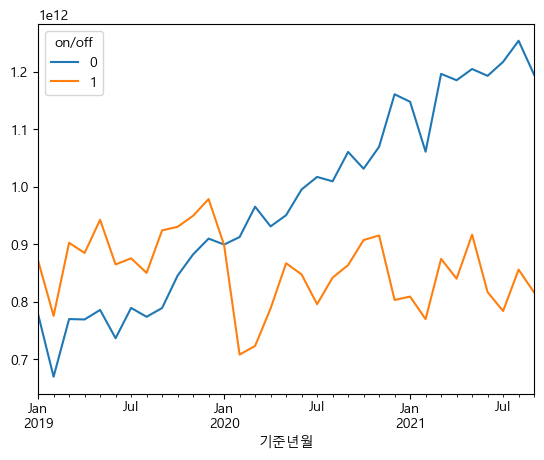

In [237]:
# groupby 함수를 이용해서 위와 같은 그래프를 생성
df.groupby(['기준년월','on/off'])['이용금액'].sum().unstack().plot()